#### This Code is our model evaluation Pipeline


In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    confusion_matrix, precision_recall_curve
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
import xgboost as xgb

from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone

RANDOM_STATE = 42

#### Generating a Training Data set

In [2]:
# --- CONFIG_MODEL_MODEL_MODEL_MODELURATION ---
# C'est ici qu'on règle la sensibilité du modèle
CONFIG_MODEL = {
    'WINDOW_RECENT_DAYS': 7,    # Période "court terme" (tendance récente)
    'WINDOW_HISTORY_DAYS': 14,  # Période "moyen terme" (pour comparaison)
    'TARGET_WINDOW': 10,        # Fenêtre de prédiction (churn dans les X prochains jours)
    'STEP_SIZE': 7,             # On avance de 7 jours à chaque itération (Data Augmentation)
    'CHURN_EVENT': 'Cancellation Confirmation'
}

#### Fetaure Engineering Code

In [ ]:
def parse_os(user_agent):
    """Extrait le système d'exploitation du User Agent"""
    if pd.isna(user_agent): return 'Unknown'
    ua = str(user_agent).lower()
    if 'iphone' in ua or 'ipad' in ua: return 'iOS'
    if 'macintosh' in ua or 'mac os' in ua: return 'Mac'
    if 'windows' in ua: return 'Windows'
    if 'linux' in ua or 'android' in ua: return 'Linux/Android'
    return 'Other'

In [4]:
def load_and_clean_data(csv_path):
    print("Chargement et Feature Engineering 'Statique'...")
    df = pd.read_parquet(csv_path)

    # 1. Dates
    df['ts_date'] = pd.to_datetime(df['ts'], unit='ms', errors='coerce')
    # La registration est souvent aussi un timestamp ms
    if 'registration' in df.columns:
        df['reg_date'] = pd.to_datetime(df['registration'], unit='ms', errors='coerce')

    # 2. Tri
    df = df.sort_values(['userId', 'ts_date']).reset_index(drop=True)
    df = df[df['userId'].notna()]

    # 3. Extraction OS (Device) - On le fait une fois ici
    if 'userAgent' in df.columns:
        df['os_type'] = df['userAgent'].apply(parse_os).astype('category')

    # 4. Conversion types
    categorical_cols = ['gender', 'level', 'page', 'method']
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    print(f"Données prêtes : {df.shape[0]} lignes.")
    return df

In [7]:
df=load_and_clean_data("../../data/churn-prediction-25-26/train.parquet")

Chargement et Feature Engineering 'Statique'...
Données prêtes : 17499636 lignes.


In [8]:
def compute_features_at_anchor(df_window, anchor_date):

    WINDOW_RECENT = 7  # On repasse à 7 jours pour lisser un peu le bruit
    WINDOW_HISTORY = 28

    start_recent = anchor_date - timedelta(days=WINDOW_RECENT)
    start_history = anchor_date - timedelta(days=WINDOW_HISTORY)

    # Filtrage global
    df_past = df_window[(df_window['ts_date'] >= start_history) & (df_window['ts_date'] <= anchor_date)].copy()
    if df_past.empty: return None

    # --- 1. GAP ANALYSIS (Conservé car crucial) ---
    df_past = df_past.sort_values(['userId', 'ts_date'])
    df_sessions = df_past.drop_duplicates(subset=['userId', 'sessionId'], keep='last').copy()
    df_sessions['prev_ts'] = df_sessions.groupby('userId')['ts_date'].shift(1)
    df_sessions['gap_days'] = (df_sessions['ts_date'] - df_sessions['prev_ts']).dt.total_seconds() / (3600 * 24)

    user_gap_stats = df_sessions.groupby('userId')['gap_days'].agg(['mean', 'last']).rename(columns={
        'mean': 'avg_gap_days',
        'last': 'last_gap_days'
    })

    # --- 2. CALCUL DU ZAPPING (NOUVEAU) ---
    # On considère qu'une chanson très courte (< 60s) ou une moyenne faible indique du zapping
    # (Note: Ce dataset a déjà des lengths calculées, on regarde la moyenne par user)
    song_stats = df_past[df_past['page'] == 'NextSong'].groupby('userId')['length'].agg(['mean', 'std']).rename(columns={
        'mean': 'avg_song_duration',
        'std': 'std_song_duration'
    })

    # --- 3. SEPARATION RECENT / HISTORY ---
    mask_recent = df_past['ts_date'] >= start_recent
    df_recent = df_past[mask_recent]
    df_history = df_past

    unique_users = df_past['userId'].unique()
    features = pd.DataFrame(index=unique_users)

    # Joindre les stats calculées
    features = features.join(user_gap_stats).join(song_stats).fillna(0)

    # Ratio d'accélération du silence
    features['gap_acceleration'] = (features['last_gap_days'] + 0.1) / (features['avg_gap_days'] + 0.1)

    # --- 4. EVENTS SPECIFIQUES ---
    def get_event_stats(df_sub, prefix):
        # Initialisation
        for col in ['page', 'song', 'sessionId', 'length']:
            if col not in df_sub.columns: df_sub[col] = 0

        stats = df_sub.groupby('userId').agg({
            'page': 'count',
            'song': 'count', # Nb chansons
            'length': 'sum', # Temps total
            'sessionId': 'nunique'
        })

        # Events critiques
        target_events = ['Roll Advert', 'Thumbs Down', 'Thumbs Up', 'Error', 'Add Friend', 'Submit Downgrade', 'Upgrade']

        events = df_sub[df_sub['page'].isin(target_events)]
        if not events.empty:
            pv = pd.crosstab(events['userId'], events['page'])
            pv = pv.reindex(columns=target_events, fill_value=0)
            stats = stats.join(pv, how='left').fillna(0)
        else:
            for col in target_events: stats[col] = 0

        stats = stats.add_prefix(f'{prefix}_')
        return stats

    feats_recent = get_event_stats(df_recent, 'recent')
    feats_history = get_event_stats(df_history, 'history')

    features = features.join(feats_recent, how='left').join(feats_history, how='left').fillna(0)

    # --- 5. RATIOS PSYCHOLOGIQUES (NOUVEAU) ---
    epsilon = 0.01

    # A. Zapping Récent vs Historique
    # On calcule la durée moyenne d'une écoute récente vs historique
    avg_len_recent = features['recent_length'] / (features['recent_song'] + epsilon)
    avg_len_history = features['history_length'] / (features['history_song'] + epsilon)

    # Si Ratio < 1 : Il écoute des morceaux plus courts qu'avant (il zappe ?)
    features['trend_song_duration'] = avg_len_recent / (avg_len_history + epsilon)

    # B. Intensité de Session (Combien de temps il reste par session ?)
    avg_sess_len_recent = features['recent_length'] / (features['recent_sessionId'] + epsilon)
    avg_sess_len_history = features['history_length'] / (features['history_sessionId'] + epsilon)

    # Si Ratio < 1 : Il fait des sessions de plus en plus courtes (Désengagement)
    features['trend_session_intensity'] = avg_sess_len_recent / (avg_sess_len_history + epsilon)

    # C. Frustration & Interactions
    features['ads_per_hour'] = features['history_Roll Advert'] / ((features['history_length'] / 3600) + epsilon)
    features['errors_per_session'] = features['history_Error'] / (features['history_sessionId'] + epsilon)

    # D. Le signal "Downgrade"
    # A-t-il essayé de downgrader récemment ? (Signal très fort de churn futur)
    features['recent_downgrade_attempt'] = (features['recent_Submit Downgrade'] > 0).astype(int)

    # Profil
    last_info = df_past.groupby('userId').last()
    if 'level' in last_info.columns: features['is_paid'] = (last_info['level'] == 'paid').astype(int)

    if 'reg_date' in last_info.columns:
        features['tenure_days'] = (anchor_date - last_info['reg_date']).dt.days
    else:
        features['tenure_days'] = 0

    last_action_date = df_past.groupby('userId')['ts_date'].max()
    features['days_since_last_action'] = (anchor_date - last_action_date).dt.total_seconds() / (3600 * 24)

    features['anchor_date'] = anchor_date
    return features

In [9]:
def run_feature_engineering_pipeline(df_logs):
    """
    Exécute la boucle Sliding Window et génère le dataset Train/Test complet.
    """
    print("Démarrage de la pipeline Sliding Window...")

    min_date = df_logs['time'].min()
    max_date = df_logs['time'].max()

    # On commence quand on a assez d'historique
    start_anchor = min_date + timedelta(days=CONFIG_MODEL['WINDOW_HISTORY_DAYS'] + CONFIG_MODEL['WINDOW_RECENT_DAYS'])
    # On s'arrête avant la fin pour avoir la vérité terrain (Target)
    end_anchor = max_date - timedelta(days=CONFIG_MODEL['TARGET_WINDOW'])

    current_date = start_anchor
    final_datasets = []

    while current_date <= end_anchor:
        print(f"Traitement de la fenêtre : {current_date.date()}")

        # 1. Générer les features (X) pour cette date
        # On passe une vue large des données pour éviter les copies inutiles
        window_start = current_date - timedelta(days=CONFIG_MODEL['WINDOW_HISTORY_DAYS'] + CONFIG_MODEL['WINDOW_RECENT_DAYS'] + 1)
        df_view = df_logs[(df_logs['time'] >= window_start) & (df_logs['time'] <= max_date)]

        features = compute_features_at_anchor(df_view, current_date)

        if features is None or features.empty:
            current_date += timedelta(days=CONFIG_MODEL['STEP_SIZE'])
            continue

        # 2. Générer la Target (Y) - Futur
        # On regarde dans le futur [Anchor, Anchor + 10 jours]
        future_mask = (df_view['time'] > current_date) & \
                      (df_view['time'] <= current_date + timedelta(days=CONFIG_MODEL['TARGET_WINDOW']))

        future_data = df_view[future_mask]

        # Identification des churners
        churn_users = future_data[future_data['page'] == CONFIG_MODEL['CHURN_EVENT']]['userId'].unique()

        features['target_churn'] = 0
        features.loc[features.index.isin(churn_users), 'target_churn'] = 1

        final_datasets.append(features)

        # Avancer
        current_date += timedelta(days=CONFIG_MODEL['STEP_SIZE'])

    # Concaténation finale
    if not final_datasets:
        print("Attention: Aucune fenêtre valide générée (dataset trop court ?)")
        return pd.DataFrame()

    full_dataset = pd.concat(final_datasets).reset_index().rename(columns={'index': 'userId'})

    print(f"Pipeline terminée. Dataset généré : {full_dataset.shape}")
    return full_dataset

In [10]:
df_train_ready = run_feature_engineering_pipeline(df)

Démarrage de la pipeline Sliding Window...
Traitement de la fenêtre : 2018-10-22
Traitement de la fenêtre : 2018-10-29
Traitement de la fenêtre : 2018-11-05
Pipeline terminée. Dataset généré : (50780, 38)


#### Finished Building Our Train Data set
In the following section we are going to

1. Split into a Train and Test set -> Test set is just the last tuesday data
2. Do Hyperparameter Tuning over all possible models 
3. Do Feature Subset Selection for the top 3 best models. 
4. Compute the Final Test set score for the best model given our training data

Locked test anchor_date (Tuesday): 2018-11-05 00:00:01
Train rows: 34459 | Test rows: 16321 | Test unique users: 16321
n_features: 35

=== Random Search: logreg ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV AUC-PR: 0.13668666730339518
Best params: {'model__C': np.float64(0.005409123677836537)}

=== Random Search: xgb ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV AUC-PR: 0.14075479386240186
Best params: {'colsample_bytree': np.float64(0.9815714308010349), 'gamma': np.float64(4.574321951102243), 'learning_rate': np.float64(0.030310114166357094), 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 429, 'reg_alpha': np.float64(2.0665795748117583e-06), 'reg_lambda': np.float64(0.4552971172077665), 'scale_pos_weight': 3, 'subsample': np.float64(0.9921326334864182)}

=== Random Search: rf ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV AUC-PR: 0.13041677260648718
Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 15, 'n_estimators': 306}

=== Random Search: et ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV AUC-PR: 0.13019898057122967
Best params: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 9, 'n_estimators': 827}

=== Random Search: hgb ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV AUC-PR: 0.13649653044623694
Best params: {'l2_regularization': np.float64(6.859693176658125), 'learning_rate': np.float64(0.03425874770068862), 'max_iter': 442, 'max_leaf_nodes': 15, 'min_samples_leaf': 23}

=== Random Search: svm ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV AUC-PR: 0.13623648773354452
Best params: {'model__estimator__C': np.float64(0.0012494702536130701)}

=== Ranking (CV mean AUC-PR) ===
xgb     0.14075
logreg  0.13669
hgb     0.13650
svm     0.13624
rf      0.13042
et      0.13020

Top 3: ['xgb', 'logreg', 'hgb']

=== Feature selection for: xgb ===
Best for xgb: dir=forward k=15 aucpr=0.14772

=== Feature selection for: logreg ===
Best for logreg: dir=backward k=10 aucpr=0.13944

=== Feature selection for: hg

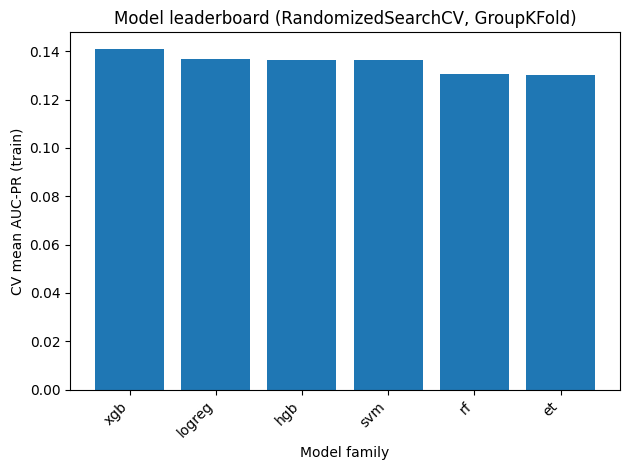

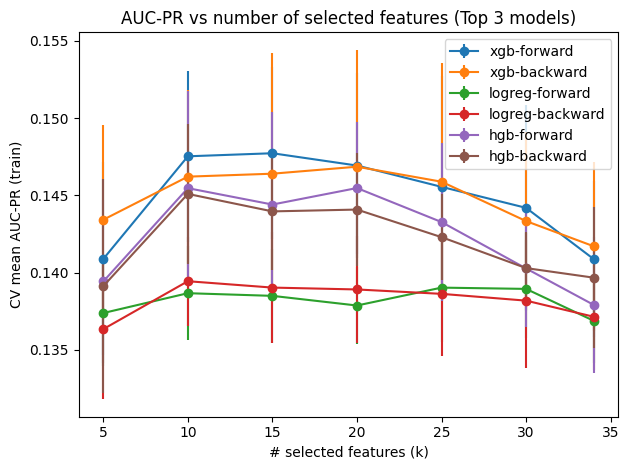

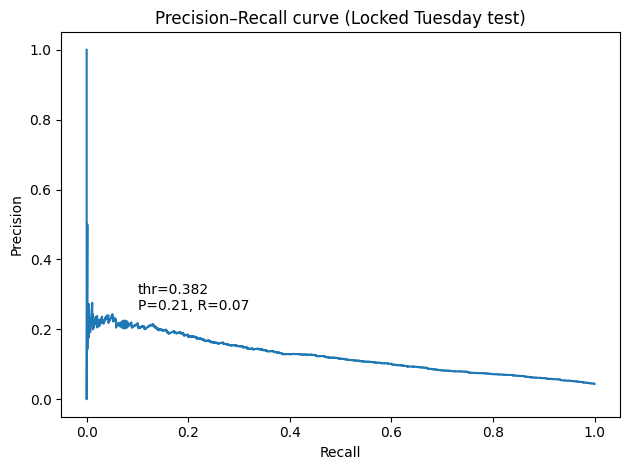

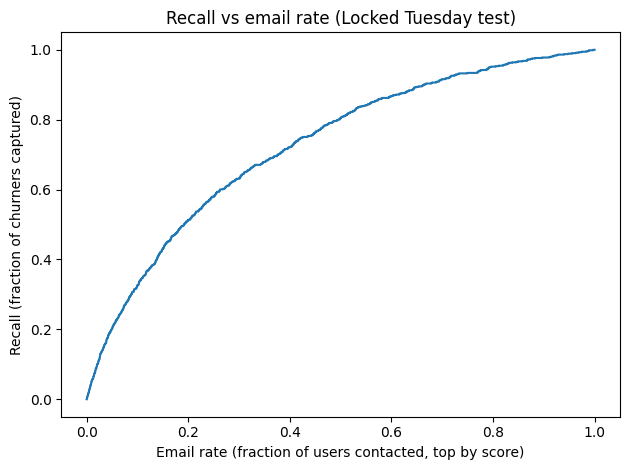

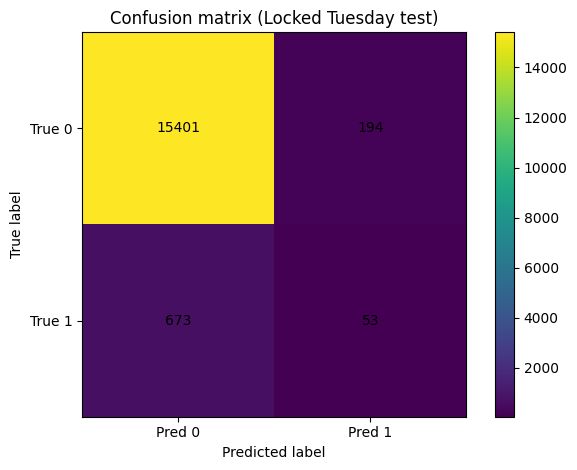

In [18]:
# =========================
# FULL PIPELINE + PLOTS
# Option A: Locked test = last Tuesday anchor_date
# Threshold tuning: maximize recall subject to precision >= MIN_PRECISION (OOF on train)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    confusion_matrix, precision_recall_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

import xgboost as xgb
from scipy.stats import loguniform, randint, uniform

RANDOM_STATE = 42
TUESDAY = 0  # Monday=0, Tuesday=1

# -------------------------
# CONFIG YOU SHOULD SET
# -------------------------
N_ITER_RANDOM_SEARCH = 40          # hyperparam trials per model family
TOP_K_MODELS = 3                   # pick best 3 families
K_LIST = [5, 10, 15, 20, 25, 30, 34]  # 34 is the max allowed when n_features=35
MIN_PRECISION = 0.25               # email is cheap -> light precision floor
CV_SPLITS = 5


# -------------------------
# Helpers
# -------------------------
def proba_or_score(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    return estimator.predict(X)


def get_oof_scores(estimator, X, y, groups, n_splits=5):
    """Out-of-fold continuous scores for threshold tuning."""
    cv = GroupKFold(n_splits=n_splits)
    oof = np.empty(len(y), dtype=float)

    for tr_idx, va_idx in cv.split(X, y, groups):
        est = clone(estimator)
        est.fit(X.iloc[tr_idx], y[tr_idx])
        oof[va_idx] = proba_or_score(est, X.iloc[va_idx])

    return oof


def tune_threshold_for_recall_with_precision(y_true, scores, min_precision=0.25):
    """
    Choose threshold maximizing recall while ensuring precision >= min_precision.
    Uses precision-recall curve.
    Returns: (threshold, achieved_precision, achieved_recall)
    """
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    best = None

    # For each threshold i, precision[i+1], recall[i+1] correspond to thresholds[i]
    for i, thr in enumerate(thresholds):
        p = precision[i + 1]
        r = recall[i + 1]
        if p >= min_precision:
            if best is None or r > best["recall"]:
                best = {"thr": float(thr), "precision": float(p), "recall": float(r)}

    if best is None:
        # If constraint impossible, fall back to max precision point
        best_idx = int(np.nanargmax(precision[1:]))
        best_thr = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
        return float(best_thr), float(precision[best_idx + 1]), float(recall[best_idx + 1])

    return best["thr"], best["precision"], best["recall"]


def precision_recall_at_threshold(y_true, scores, thr):
    y_pred = (scores >= thr).astype(int)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    prec = tp / (tp + fp + 1e-12)
    rec = tp / (tp + fn + 1e-12)
    return float(prec), float(rec)


# -------------------------
# Models + search spaces
# -------------------------
def build_estimator(model_type: str):
    mt = model_type.lower()

    if mt == "xgb":
        # NOTE: no early stopping inside CV; tune n_estimators instead
        return xgb.XGBClassifier(
            eval_metric="aucpr",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            tree_method="hist",
        )

    if mt == "logreg":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                solver="lbfgs",
            ))
        ])

    if mt == "rf":
        return RandomForestClassifier(
            n_jobs=-1,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )

    if mt == "et":
        return ExtraTreesClassifier(
            n_jobs=-1,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )

    if mt == "hgb":
        return HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
        )

    if mt == "svm":
        base = LinearSVC(
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        )
        calibrated = CalibratedClassifierCV(base, method="sigmoid", cv=3)
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", calibrated),
        ])

    raise ValueError(f"Unknown model_type: {model_type}")


def param_distributions(model_type: str):
    mt = model_type.lower()

    if mt == "xgb":
        return {
            "n_estimators": randint(150, 700),
            "learning_rate": loguniform(0.01, 0.2),
            "max_depth": randint(2, 9),
            "subsample": uniform(0.6, 0.4),
            "colsample_bytree": uniform(0.6, 0.4),
            "min_child_weight": randint(1, 15),
            "gamma": uniform(0.0, 5.0),
            "reg_alpha": loguniform(1e-8, 1e-1),
            "reg_lambda": loguniform(1e-2, 10.0),
            "scale_pos_weight": randint(1, 25),
        }

    if mt == "logreg":
        return {"model__C": loguniform(1e-3, 50.0)}

    if mt == "svm":
        # Pipeline -> model (CalibratedClassifierCV) -> base_estimator (LinearSVC)
        return {"model__estimator__C": loguniform(1e-3, 50.0)}

    if mt == "rf":
        return {
            "n_estimators": randint(200, 700),
            "max_depth": [None, 5, 10, 20, 30],
            "min_samples_leaf": randint(1, 20),
            "max_features": ["sqrt", "log2", None],
        }

    if mt == "et":
        return {
            "n_estimators": randint(200, 900),
            "max_depth": [None, 5, 10, 20, 30],
            "min_samples_leaf": randint(1, 10),
            "max_features": ["sqrt", "log2", None],
        }

    if mt == "hgb":
        return {
            "learning_rate": loguniform(0.01, 0.2),
            "max_leaf_nodes": randint(15, 80),
            "min_samples_leaf": randint(5, 60),
            "l2_regularization": loguniform(1e-6, 10.0),
            "max_iter": randint(100, 600),
        }

    raise ValueError(model_type)


def tune_random_search(model_type: str, X, y, groups, n_iter=40):
    est = build_estimator(model_type)
    dist = param_distributions(model_type)
    cv = GroupKFold(n_splits=CV_SPLITS)

    search = RandomizedSearchCV(
        estimator=est,
        param_distributions=dist,
        n_iter=n_iter,
        scoring="average_precision",   # AUC-PR
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
        refit=True
    )
    search.fit(X, y, groups=groups)
    return search


def sfs_curve_for_model(best_estimator, X, y, groups, k_list, direction, n_splits=5):
    """
    Group-aware SFS without metadata routing:
    - Precompute GroupKFold splits and pass them as cv=...
    - Do NOT pass groups to selector.fit(...)
    """
    gkf = GroupKFold(n_splits=n_splits)
    splits = list(gkf.split(X, y, groups))   # <-- group-aware splits

    rows = []
    for k in k_list:
        selector = SequentialFeatureSelector(
            estimator=best_estimator,
            n_features_to_select=k,
            direction=direction,
            scoring="average_precision",
            cv=splits,        # <-- use precomputed group splits
            n_jobs=-1
        )

        selector.fit(X, y)    # <-- no groups here
        selected_cols = list(X.columns[selector.get_support()])

        # Evaluate selected set with the same group-aware splits
        scores = []
        for tr_idx, va_idx in splits:
            Xtr, Xva = X.iloc[tr_idx][selected_cols], X.iloc[va_idx][selected_cols]
            ytr, yva = y[tr_idx], y[va_idx]

            est = clone(best_estimator)
            est.fit(Xtr, ytr)
            s = proba_or_score(est, Xva)
            scores.append(average_precision_score(yva, s))

        rows.append({
            "k": k,
            "direction": direction,
            "mean_aucpr": float(np.mean(scores)),
            "std_aucpr": float(np.std(scores)),
            "selected_cols": selected_cols
        })

    return pd.DataFrame(rows)


# =========================
# RUN PIPELINE
# =========================

# ---- 1) Split: locked test = last Tuesday anchor_date
df_all = df_train_ready.copy()
df_all["anchor_date"] = pd.to_datetime(df_all["anchor_date"])

DROP = {"userId", "anchor_date", "target_churn"}
feature_cols = [c for c in df_all.columns if c not in DROP]

tuesday_anchors = df_all.loc[df_all["anchor_date"].dt.weekday == TUESDAY, "anchor_date"].sort_values().unique()
if len(tuesday_anchors) == 0:
    raise ValueError("No Tuesday anchor_date found in df_train_ready.")
last_tuesday = tuesday_anchors[-1]

train_df = df_all[df_all["anchor_date"] < last_tuesday].copy()
test_df  = df_all[df_all["anchor_date"] == last_tuesday].copy()

X_train = train_df[feature_cols]
y_train = train_df["target_churn"].astype(int).values
g_train = train_df["userId"].values

X_test = test_df[feature_cols]
y_test = test_df["target_churn"].astype(int).values
g_test = test_df["userId"].values

print("Locked test anchor_date (Tuesday):", last_tuesday)
print("Train rows:", len(train_df), "| Test rows:", len(test_df), "| Test unique users:", test_df["userId"].nunique())
print("n_features:", len(feature_cols))


# ---- 2) Hyperparameter tuning for all model families
model_types = ["logreg", "xgb", "rf", "et", "hgb", "svm"]
random_search_results = {}

for mt in model_types:
    print("\n=== Random Search:", mt, "===")
    rs = tune_random_search(mt, X_train, y_train, g_train, n_iter=N_ITER_RANDOM_SEARCH)
    random_search_results[mt] = rs
    print("Best CV AUC-PR:", rs.best_score_)
    print("Best params:", rs.best_params_)


# ---- 3) Rank models + pick top 3
ranking = sorted(
    [(mt, random_search_results[mt].best_score_, random_search_results[mt].best_estimator_)
     for mt in model_types],
    key=lambda x: x[1],
    reverse=True
)

print("\n=== Ranking (CV mean AUC-PR) ===")
for mt, score, _ in ranking:
    print(f"{mt:6s}  {score:.5f}")

top3 = ranking[:TOP_K_MODELS]
top3_types = [x[0] for x in top3]
top3_estimators = {mt: est for mt, _, est in top3}

print("\nTop 3:", top3_types)


# ---- 4) Feature subset selection (forward + backward) for top 3
fs_results = {}
for mt in top3_types:
    print("\n=== Feature selection for:", mt, "===")
    best_est = top3_estimators[mt]

    df_fwd = sfs_curve_for_model(best_est, X_train, y_train, g_train, K_LIST, "forward", n_splits=CV_SPLITS)
    df_bwd = sfs_curve_for_model(best_est, X_train, y_train, g_train, K_LIST, "backward", n_splits=CV_SPLITS)

    fs_results[mt] = pd.concat([df_fwd, df_bwd], ignore_index=True)

    best_row = fs_results[mt].sort_values("mean_aucpr", ascending=False).iloc[0]
    print(f"Best for {mt}: dir={best_row['direction']} k={best_row['k']} aucpr={best_row['mean_aucpr']:.5f}")


# ---- 5) Choose final pipeline from TRAIN CV results (across top 3 + FS)
cand = []
for mt in top3_types:
    tmp = fs_results[mt].copy()
    tmp["model_type"] = mt
    cand.append(tmp)
cand = pd.concat(cand, ignore_index=True)

best_global = cand.sort_values("mean_aucpr", ascending=False).iloc[0]
final_model_type = best_global["model_type"]
final_cols = best_global["selected_cols"]
final_estimator = top3_estimators[final_model_type]

print("\n=== FINAL CHOICE (from TRAIN CV) ===")
print("Model:", final_model_type)
print("FS direction:", best_global["direction"], "| k:", int(best_global["k"]))
print("Train CV AUC-PR:", float(best_global["mean_aucpr"]))


# ---- 6) Threshold tuning on TRAIN only (OOF), tuned for recall with precision floor
oof_scores = get_oof_scores(final_estimator, X_train[final_cols], y_train, g_train, n_splits=CV_SPLITS)
thr, oof_prec, oof_rec = tune_threshold_for_recall_with_precision(y_train, oof_scores, min_precision=MIN_PRECISION)

print("\n=== THRESHOLD (tuned on TRAIN OOF) ===")
print("Objective: max recall subject to precision >=", MIN_PRECISION)
print("Chosen threshold:", thr)
print("OOF precision:", oof_prec, "| OOF recall:", oof_rec)


# ---- 7) Fit final model on ALL train, evaluate ONCE on locked test
final_estimator.fit(X_train[final_cols], y_train)
test_scores = proba_or_score(final_estimator, X_test[final_cols])

test_aucpr = average_precision_score(y_test, test_scores)
test_rocauc = roc_auc_score(y_test, test_scores)
test_prec_at_thr, test_rec_at_thr = precision_recall_at_threshold(y_test, test_scores, thr)

y_pred = (test_scores >= thr).astype(int)
cm = confusion_matrix(y_test, y_pred)

print("\n=== LOCKED TEST RESULTS (Tuesday) ===")
print("AUC-PR:", round(test_aucpr, 5))
print("ROC-AUC:", round(test_rocauc, 5))
print("Threshold:", float(thr))
print("Precision@thr:", round(test_prec_at_thr, 5), "| Recall@thr:", round(test_rec_at_thr, 5))
print("Confusion matrix:\n", cm)


# =========================
# PLOTS
# =========================

# ---- Plot 1: Model leaderboard (CV AUC-PR from hyperparam tuning)
plt.figure()
names = [x[0] for x in ranking]
scores = [x[1] for x in ranking]
plt.bar(names, scores)
plt.xlabel("Model family")
plt.ylabel("CV mean AUC-PR (train)")
plt.title("Model leaderboard (RandomizedSearchCV, GroupKFold)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()


# ---- Plot 2: AUC-PR vs #features for top 3 (forward/backward)
plt.figure()
for mt in top3_types:
    dfp = fs_results[mt]
    for direction in ["forward", "backward"]:
        d = dfp[dfp["direction"] == direction].sort_values("k")
        plt.errorbar(d["k"], d["mean_aucpr"], yerr=d["std_aucpr"], marker="o", label=f"{mt}-{direction}")
plt.xlabel("# selected features (k)")
plt.ylabel("CV mean AUC-PR (train)")
plt.title("AUC-PR vs number of selected features (Top 3 models)")
plt.legend()
plt.tight_layout()


# ---- Plot 3: Precision-Recall curve on locked test + tuned threshold marker
precision, recall, thresholds = precision_recall_curve(y_test, test_scores)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve (Locked Tuesday test)")

# Add tuned threshold marker (approx)
p_thr, r_thr = test_prec_at_thr, test_rec_at_thr
plt.scatter([r_thr], [p_thr])
plt.annotate(f"thr={thr:.3f}\nP={p_thr:.2f}, R={r_thr:.2f}",
             (r_thr, p_thr), textcoords="offset points", xytext=(10, 10))
plt.tight_layout()


# ---- Plot 4: Recall vs Email Rate curve (top X% outreach)
# Sort by score descending, compute cumulative recall as you email more users
order = np.argsort(-test_scores)
y_sorted = y_test[order]
cum_tp = np.cumsum(y_sorted == 1)
total_pos = np.sum(y_test == 1) + 1e-12
email_rate = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
recall_curve = cum_tp / total_pos

plt.figure()
plt.plot(email_rate, recall_curve)
plt.xlabel("Email rate (fraction of users contacted, top by score)")
plt.ylabel("Recall (fraction of churners captured)")
plt.title("Recall vs email rate (Locked Tuesday test)")
plt.tight_layout()


# ---- Plot 5: Confusion matrix heatmap (simple matplotlib)
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion matrix (Locked Tuesday test)")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Pred 0", "Pred 1"])
plt.yticks(tick_marks, ["True 0", "True 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()

plt.show()
